# Quadratic Discriminant Analysis (QDA) sur MNIST
Cette analyse montre comment appliquer la méthode QDA sur le dataset complet MNIST, étape par étape, avec des commentaires explicatifs.

## Objectif
- Utiliser le dataset complet MNIST (70 000 images, 784 pixels)
- Préparer les données et normaliser les pixels
- Entraîner un modèle QDA sur cet espace
- Mesurer la performance avec accuracy et matrice de confusion

In [9]:
# Import des bibliothèques nécessaires
# NumPy et pandas pour la manipulation des données.
import numpy as np
import pandas as pd

# Visualisation des résultats.
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset et séparation train/test.
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Normalisation avant entraînement QDA.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modèle QDA et métriques d'évaluation.

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Chargement du dataset MNIST complet
Nous utilisons `fetch_openml('mnist_784')` pour récupérer les 70 000 images et leurs labels.

In [10]:
# Chargement des données MNIST depuis OpenML
# On récupère les 70 000 images en format NumPy et les labels associés.
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Conversion des étiquettes en entiers pour l'entraînement.
y = y.astype(int)

# Vérification des dimensions des données.
print('Dataset shape:', X.shape)
print('Labels shape:', y.shape)
print('Classes:', np.unique(y))

c:\Users\zemza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Dataset shape: (70000, 784)
Labels shape: (70000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


## Préparation des données
- Séparation train/test
- Normalisation des pixels
- QDA est sensible aux échelles, d'où l'importance du `StandardScaler`.

In [11]:
# Séparation entre données d'entraînement et de test.
# On utilise 20% des données pour le test et on conserve la proportion de chaque classe.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

# Mise à l'échelle standard des pixels.
# QDA est sensible à l'échelle, donc on normalise pour stabiliser l'entraînement.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vérification des premières statistiques après normalisation.
print('Scaled train mean (first 5 features):', np.mean(X_train_scaled, axis=0)[:5])
print('Scaled train std (first 5 features):', np.std(X_train_scaled, axis=0)[:5])

Train shape: (56000, 784) Test shape: (14000, 784)
Scaled train mean (first 5 features): [0. 0. 0. 0. 0.]
Scaled train std (first 5 features): [0. 0. 0. 0. 0.]


## Entraînement du modèle QDA
QDA estime une covariance par classe. C'est donc plus flexible que LDA, mais aussi plus coûteux en données et en calcul.

In [12]:
# Création du modèle QDA.
# QDA estime une matrice de covariance distincte pour chaque classe.
qda = QuadraticDiscriminantAnalysis()

# Entraînement du modèle sur les données normalisées d'entraînement.
qda.fit(X_train_scaled, y_train)
print('QDA model trained successfully')

c:\Users\zemza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QDA model trained successfully


## Visualisation 2D

Nous utilisons une réduction de dimension avec PCA sur les données normalisées pour visualiser la distribution des classes avant et après la séparation train/test.

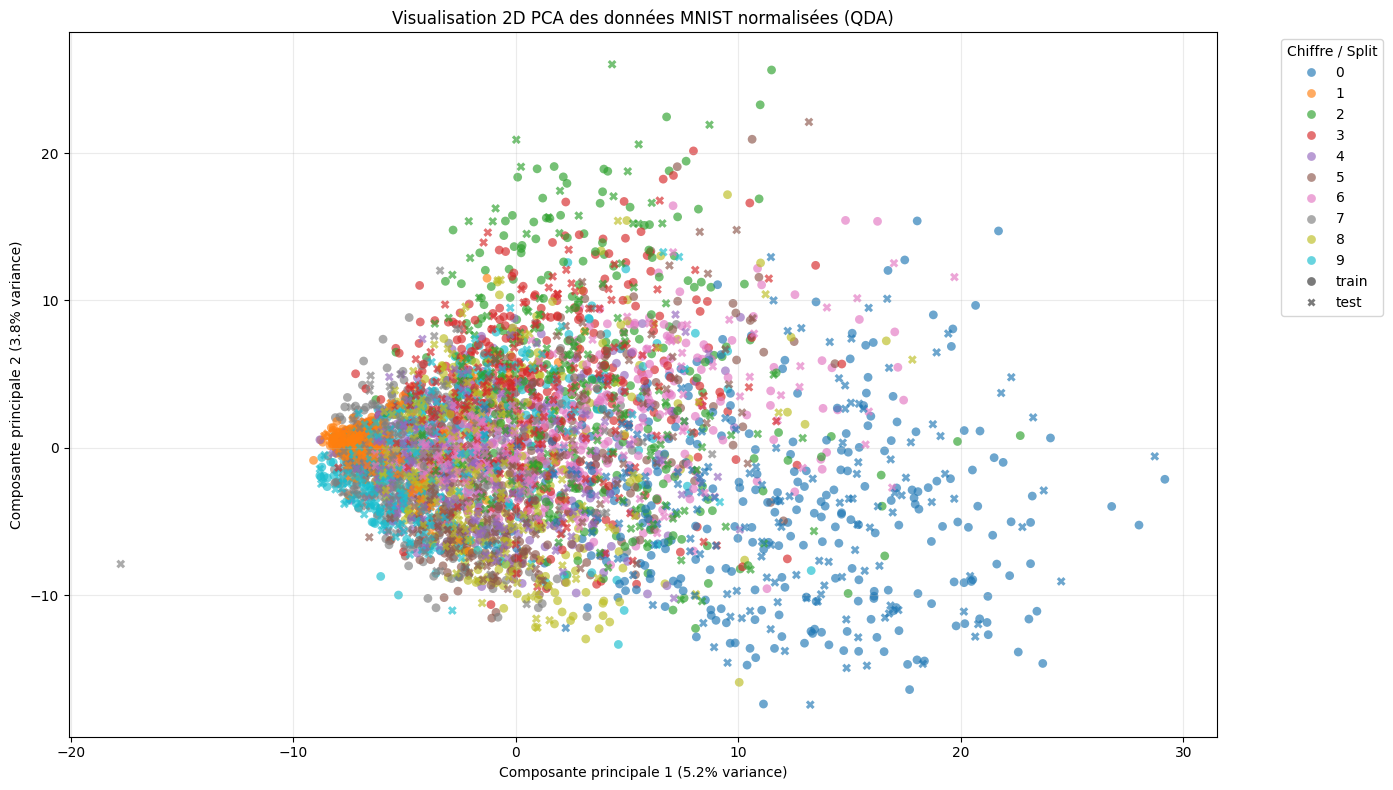

✅ Visualisation 2D ajoutée avec PCA.
💡 On observe les classes de chiffres et la séparation train/test sur les deux premières composantes.


In [13]:
# Visualisation 2D des données normalisées avec PCA
# Pour garder le graphique lisible, nous utilisons un sous-échantillon représentatif.
rng = np.random.default_rng(42)
train_idx = rng.choice(X_train_scaled.shape[0], size=3000, replace=False)
test_idx = rng.choice(X_test_scaled.shape[0], size=1500, replace=False)

X_vis = np.vstack([X_train_scaled[train_idx], X_test_scaled[test_idx]])
y_vis = np.concatenate([y_train[train_idx], y_test[test_idx]])
split_vis = np.array(['train'] * len(train_idx) + ['test'] * len(test_idx))

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_vis_2d = pca.fit_transform(X_vis)

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    x=X_vis_2d[:, 0],
    y=X_vis_2d[:, 1],
    hue=y_vis,
    style=split_vis,
    palette='tab10',
    alpha=0.65,
    s=40,
    edgecolor='none'
)

plt.title('Visualisation 2D PCA des données MNIST normalisées (QDA)')
plt.xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Chiffre / Split', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('✅ Visualisation 2D ajoutée avec PCA.')
print('💡 On observe les classes de chiffres et la séparation train/test sur les deux premières composantes.')

## Évaluation du modèle
Nous calculons l'accuracy et la matrice de confusion pour comprendre les erreurs du modèle.

In [14]:
# Prédiction des étiquettes sur l'ensemble de test normalisé.
y_pred = qda.predict(X_test_scaled)

# Calcul des métriques de performance.
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'QDA accuracy on MNIST test set: {accuracy:.4f}')
print('Classification report:')
print(classification_report(y_test, y_pred))

QDA accuracy on MNIST test set: 0.5509
Classification report:
              precision    recall  f1-score   support

           0       0.35      0.97      0.52      1381
           1       0.82      0.94      0.87      1575
           2       0.84      0.22      0.35      1398
           3       0.62      0.30      0.41      1428
           4       0.85      0.13      0.22      1365
           5       0.86      0.17      0.28      1263
           6       0.74      0.94      0.83      1375
           7       0.92      0.31      0.46      1459
           8       0.47      0.51      0.49      1365
           9       0.42      0.95      0.58      1391

    accuracy                           0.55     14000
   macro avg       0.69      0.54      0.50     14000
weighted avg       0.69      0.55      0.51     14000



## Analyse de la matrice de confusion
La matrice de confusion montre quelles classes sont confondues. Cela aide à identifier les paires de chiffres les plus difficiles à distinguer.

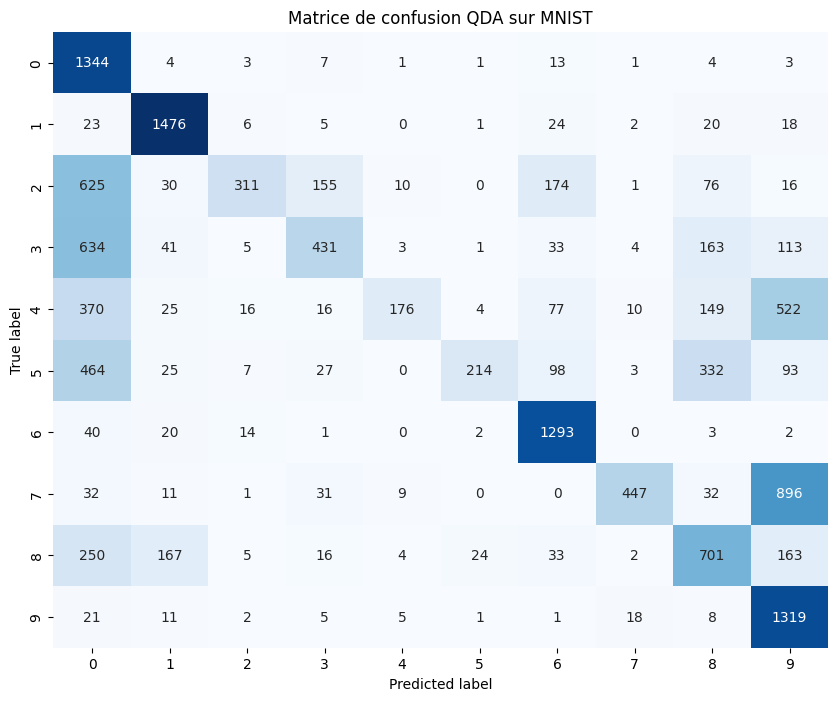

In [15]:
# Visualisation de la matrice de confusion pour analyser les erreurs du modèle.
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de confusion QDA sur MNIST')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

## Résumé et conclusions
- QDA est une méthode supervisée qui permet des frontières de décision quadratiques.
- Elle est particulièrement utile lorsque chaque classe a sa propre forme de dispersion.
- Sur le dataset MNIST complet, QDA peut être plus lourd à entraîner, mais fournit une alternative intéressante à LDA pour des distributions non homogènes.